In [1]:
import torch
from torch import nn
import torchvision
import torchvision.transforms as transforms

import numpy as np

from common_utils import NeuralNetwork, EarlyStopper
from common_utils import train_loop, test_loop
from common_utils import device, set_seed

Using mps device


In [2]:
batch_size = 256
max_epochs = 100
patience = 10

print(f"Using {device} device")
set_seed(0)

Using mps device


In [ ]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_dataloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=4)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_dataloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=4)

In [4]:
model = NeuralNetwork(hidden_size=50).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())
early_stopper = EarlyStopper(patience=patience, min_delta=0)

tr1_loss, tr1_correct = [], []
te1_loss, te1_correct = [], []
for t in range(max_epochs):
    train_loss, train_correct = train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loss, test_correct = test_loop(test_dataloader, model, loss_fn)
    
    tr1_loss.append(train_loss), tr1_correct.append(train_correct)
    te1_loss.append(test_loss), te1_correct.append(test_correct)
    
    
    print(f"Epoch {t+1}: Train_accuracy: {(100*train_correct):>0.2f}%, Train_loss: {train_loss:>8f}, Test_accuracy: {(100*test_correct):>0.2f}%, Test_loss: {test_loss:>8f}")
    
    if early_stopper.early_stop(test_loss): 
        print("Done!")
        break

Epoch 1: Train_accuracy: 28.38%, Train_loss: 0.008517, Test_accuracy: 36.27%, Test_loss: 0.008368
Epoch 2: Train_accuracy: 38.02%, Train_loss: 0.008151, Test_accuracy: 39.38%, Test_loss: 0.008249
Epoch 3: Train_accuracy: 40.99%, Train_loss: 0.008032, Test_accuracy: 41.33%, Test_loss: 0.008178
Epoch 4: Train_accuracy: 42.98%, Train_loss: 0.007957, Test_accuracy: 41.88%, Test_loss: 0.008150
Epoch 5: Train_accuracy: 45.10%, Train_loss: 0.007879, Test_accuracy: 42.27%, Test_loss: 0.008127
Epoch 6: Train_accuracy: 47.00%, Train_loss: 0.007812, Test_accuracy: 42.73%, Test_loss: 0.008109
Epoch 7: Train_accuracy: 47.85%, Train_loss: 0.007769, Test_accuracy: 43.70%, Test_loss: 0.008072
Epoch 8: Train_accuracy: 49.04%, Train_loss: 0.007727, Test_accuracy: 43.85%, Test_loss: 0.008092
Epoch 9: Train_accuracy: 49.80%, Train_loss: 0.007695, Test_accuracy: 44.02%, Test_loss: 0.008065
Epoch 10: Train_accuracy: 50.94%, Train_loss: 0.007652, Test_accuracy: 44.57%, Test_loss: 0.008049
Epoch 11: Train_acc

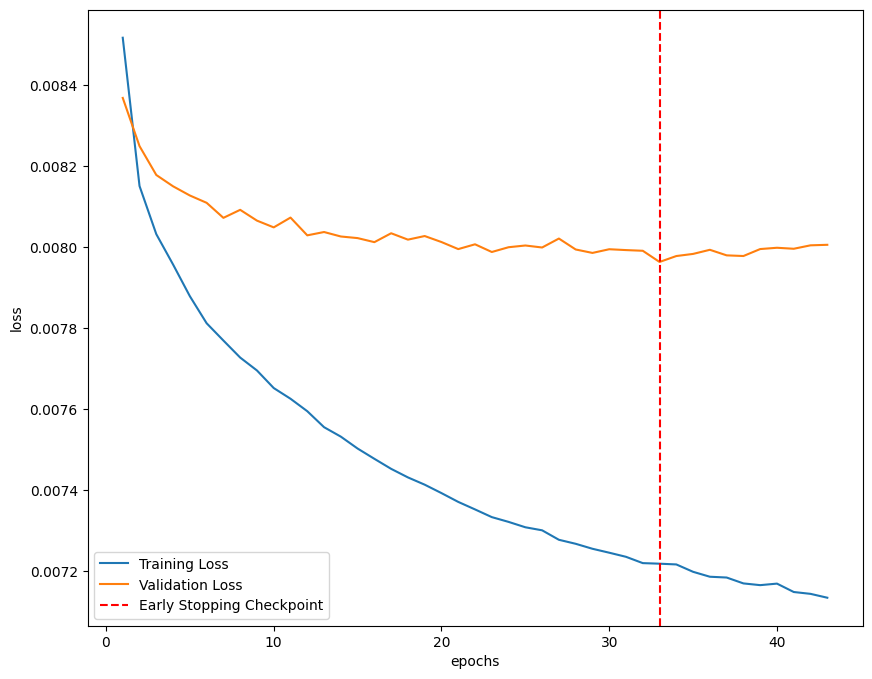

In [5]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,8))
plt.plot(range(1,len(tr1_loss)+1),tr1_loss, label='Training Loss')
plt.plot(range(1,len(te1_loss)+1),te1_loss,label='Validation Loss')

# find position of lowest validation loss
minposs = te1_loss.index(min(te1_loss))+1 
plt.axvline(minposs, linestyle='--', color='r',label='Early Stopping Checkpoint')

plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [6]:
model = NeuralNetwork(hidden_size=100).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())
early_stopper = EarlyStopper(patience=patience, min_delta=0)

tr2_loss, tr2_correct = [], []
te2_loss, te2_correct = [], []
for t in range(max_epochs):
    train_loss, train_correct = train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loss, test_correct = test_loop(test_dataloader, model, loss_fn)
    
    tr2_loss.append(train_loss), tr2_correct.append(train_correct)
    te2_loss.append(test_loss), te2_correct.append(test_correct)
    
    
    print(f"Epoch {t+1}: Train_accuracy: {(100*train_correct):>0.2f}%, Train_loss: {train_loss:>8f}, Test_accuracy: {(100*test_correct):>0.2f}%, Test_loss: {test_loss:>8f}")
    
    if early_stopper.early_stop(test_loss): 
        print("Done!")
        break

Epoch 1: Train_accuracy: 29.99%, Train_loss: 0.008442, Test_accuracy: 37.57%, Test_loss: 0.008326
Epoch 2: Train_accuracy: 38.48%, Train_loss: 0.008119, Test_accuracy: 40.17%, Test_loss: 0.008207
Epoch 3: Train_accuracy: 42.12%, Train_loss: 0.007991, Test_accuracy: 41.20%, Test_loss: 0.008177
Epoch 4: Train_accuracy: 44.51%, Train_loss: 0.007896, Test_accuracy: 43.23%, Test_loss: 0.008093
Epoch 5: Train_accuracy: 46.47%, Train_loss: 0.007821, Test_accuracy: 43.82%, Test_loss: 0.008074
Epoch 6: Train_accuracy: 47.94%, Train_loss: 0.007759, Test_accuracy: 43.92%, Test_loss: 0.008052
Epoch 7: Train_accuracy: 49.25%, Train_loss: 0.007712, Test_accuracy: 44.05%, Test_loss: 0.008062
Epoch 8: Train_accuracy: 50.79%, Train_loss: 0.007654, Test_accuracy: 44.67%, Test_loss: 0.008038
Epoch 9: Train_accuracy: 51.92%, Train_loss: 0.007613, Test_accuracy: 45.88%, Test_loss: 0.007993
Epoch 10: Train_accuracy: 53.19%, Train_loss: 0.007566, Test_accuracy: 45.45%, Test_loss: 0.008004
Epoch 11: Train_acc

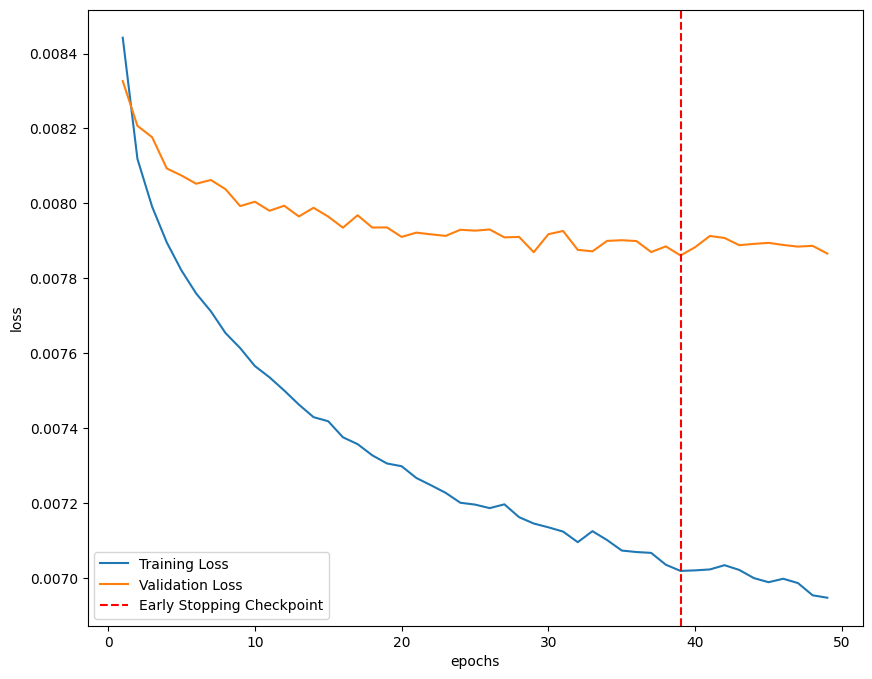

In [7]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,8))
plt.plot(range(1,len(tr2_loss)+1),tr2_loss, label='Training Loss')
plt.plot(range(1,len(te2_loss)+1),te2_loss,label='Validation Loss')

# find position of lowest validation loss
minposs = te2_loss.index(min(te2_loss))+1 
plt.axvline(minposs, linestyle='--', color='r',label='Early Stopping Checkpoint')

plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [ ]:
model = NeuralNetwork(hidden_size=400).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())
early_stopper = EarlyStopper(patience=patience, min_delta=0)

tr3_loss, tr3_correct = [], []
te3_loss, te3_correct = [], []
for t in range(max_epochs):
    train_loss, train_correct = train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loss, test_correct = test_loop(test_dataloader, model, loss_fn)
    
    tr3_loss.append(train_loss), tr3_correct.append(train_correct)
    te3_loss.append(test_loss), te3_correct.append(test_correct)
    
    
    print(f"Epoch {t+1}: Train_accuracy: {(100*train_correct):>0.2f}%, Train_loss: {train_loss:>8f}, Test_accuracy: {(100*test_correct):>0.2f}%, Test_loss: {test_loss:>8f}")
    
    if early_stopper.early_stop(test_loss): 
        print("Done!")
        break

Epoch 1: Train_accuracy: 30.06%, Train_loss: 0.008432, Test_accuracy: 32.90%, Test_loss: 0.008489
Epoch 2: Train_accuracy: 35.29%, Train_loss: 0.008239, Test_accuracy: 36.75%, Test_loss: 0.008355
Epoch 3: Train_accuracy: 38.20%, Train_loss: 0.008128, Test_accuracy: 41.20%, Test_loss: 0.008189
Epoch 4: Train_accuracy: 40.39%, Train_loss: 0.008045, Test_accuracy: 38.50%, Test_loss: 0.008292
Epoch 5: Train_accuracy: 40.86%, Train_loss: 0.008029, Test_accuracy: 39.75%, Test_loss: 0.008244
Epoch 6: Train_accuracy: 42.75%, Train_loss: 0.007957, Test_accuracy: 38.42%, Test_loss: 0.008301
Epoch 7: Train_accuracy: 42.35%, Train_loss: 0.007975, Test_accuracy: 41.12%, Test_loss: 0.008189
Epoch 8: Train_accuracy: 43.92%, Train_loss: 0.007916, Test_accuracy: 40.58%, Test_loss: 0.008209
Epoch 9: Train_accuracy: 44.41%, Train_loss: 0.007897, Test_accuracy: 41.40%, Test_loss: 0.008174
Epoch 10: Train_accuracy: 45.39%, Train_loss: 0.007860, Test_accuracy: 40.58%, Test_loss: 0.008213
Epoch 11: Train_acc

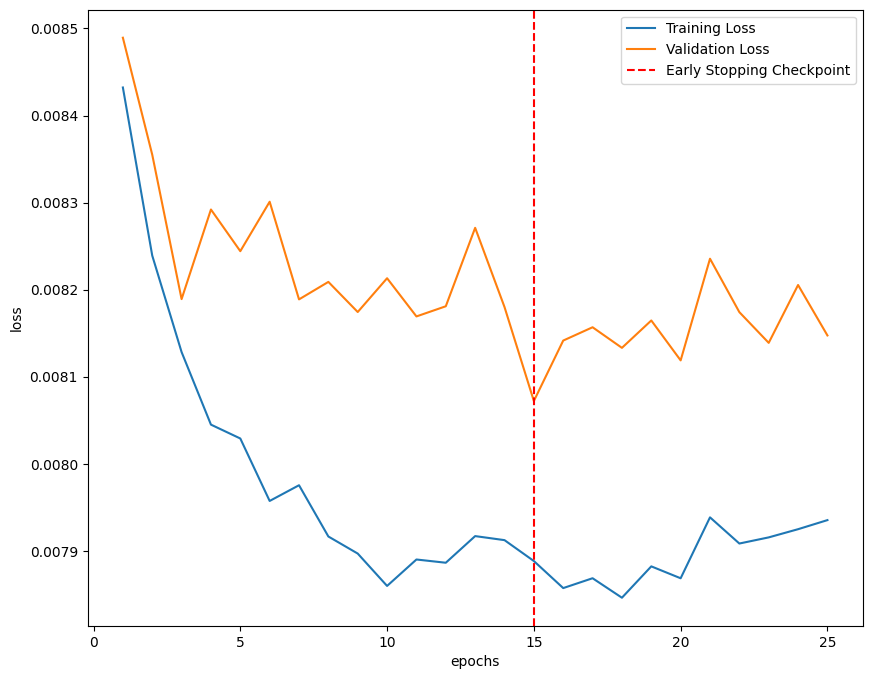

In [9]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,8))
plt.plot(range(1,len(tr3_loss)+1),tr3_loss, label='Training Loss')
plt.plot(range(1,len(te3_loss)+1),te3_loss,label='Validation Loss')

# find position of lowest validation loss
minposs = te3_loss.index(min(te3_loss))+1 
plt.axvline(minposs, linestyle='--', color='r',label='Early Stopping Checkpoint')

plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

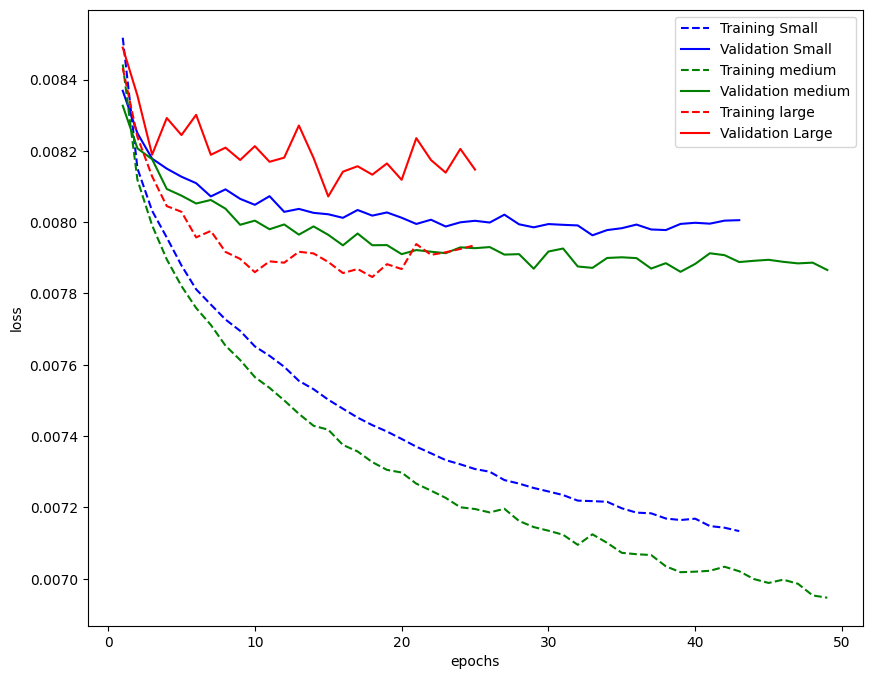

In [10]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,8))
plt.plot(range(1,len(tr1_loss)+1),tr1_loss, linestyle = '--', color = 'b', label='Training Small')
plt.plot(range(1,len(te1_loss)+1),te1_loss, color = 'b', label='Validation Small')
plt.plot(range(1,len(tr2_loss)+1),tr2_loss, linestyle = '--', color = 'g', label='Training medium')
plt.plot(range(1,len(te2_loss)+1),te2_loss, color = 'g', label='Validation medium')
plt.plot(range(1,len(tr3_loss)+1),tr3_loss, linestyle = '--', color = 'r', label='Training large')
plt.plot(range(1,len(te3_loss)+1),te3_loss, color = 'r', label='Validation Large')

plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()